# Input library and dataset

In [22]:
!pip install -r requirements.txt




[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import os
import cv2
import time
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import torch
from torch import nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


class color:
    PURPLE = '\033[95m'
    CYAN = '\033[96m'
    DARKCYAN = '\033[36m'
    BLUE = '\033[94m'
    GREEN = '\033[92m'
    YELLOW = '\033[93m'
    RED = '\033[91m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'
    END = '\033[0m'

In [24]:
dataset_dir = 'Dataset'

df = pd.read_json(path_or_buf=os.path.join(dataset_dir,'module_metadata.json'), orient='index').sort_index()
df = df.assign(image_filepath=df.image_filepath.apply(lambda x:os.path.join(dataset_dir,x)))

df = df.assign(status=df.anomaly_class.apply(lambda x: 'Faulty' if x!='No-Anomaly' else 'Normal'))
classification_type = 'status';df

,image_filepath,anomaly_class,status
0,Dataset\images/0.jpg,Offline-Module,Faulty
1,Dataset\images/1.jpg,Offline-Module,Faulty
2,Dataset\images/2.jpg,Offline-Module,Faulty
3,Dataset\images/3.jpg,Offline-Module,Faulty
4,Dataset\images/4.jpg,Offline-Module,Faulty
...,...,...,...
19995,Dataset\images/19995.jpg,No-Anomaly,Normal
19996,Dataset\images/19996.jpg,No-Anomaly,Normal
19997,Dataset\images/19997.jpg,No-Anomaly,Normal
19998,Dataset\images/19998.jpg,No-Anomaly,Normal


In [25]:
df.status.value_counts()

status
Faulty    10000
Normal    10000
Name: count, dtype: int64

In [26]:
def plot(anomaly_type='all', plot_type='jet'):

    if anomaly_type == 'all':        
        sample = df.groupby('anomaly_class').sample()
    else:
        sample = df[df['anomaly_class']==anomaly_type].sample(12)
        
    plt.figure(figsize=(20,20))
    for i, (image_path, class_name, _) in enumerate(sample.values, start=1):
        image = cv2.imread(image_path, 0)
    
        plt.subplot(2, 6, i)
        plt.imshow(image, cmap=plot_type)
        plt.subplots_adjust(top=0.52, hspace=0.2)
        plt.title(class_name,fontsize=20)
        plt.axis('off')
    plt.show()

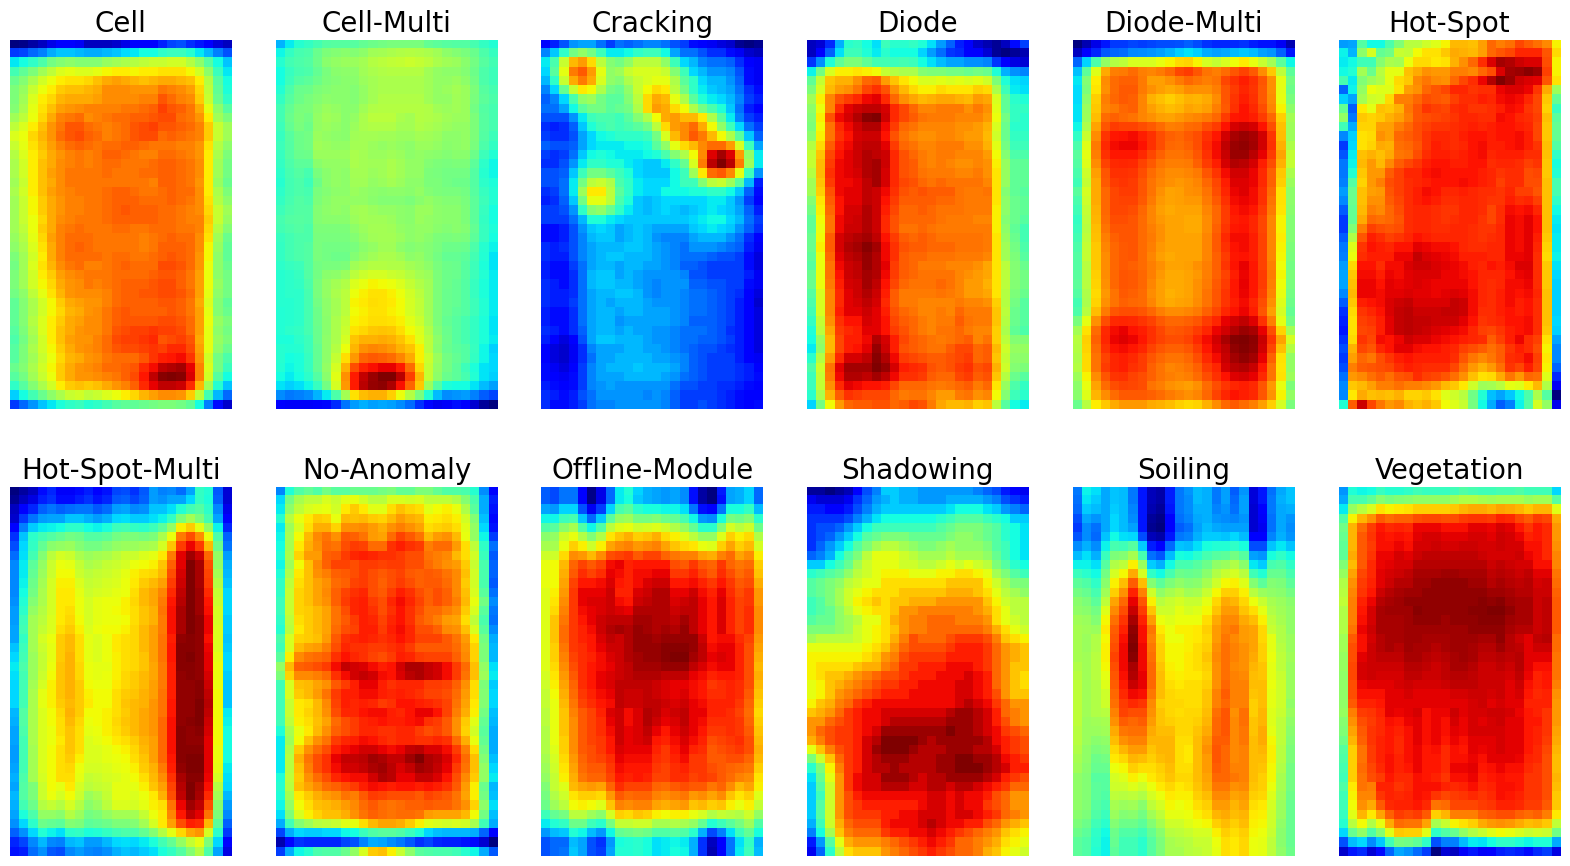

In [27]:
plot()

In [28]:
def split_data(df):

    # Create empty DataFrames for each split
    df_train = pd.DataFrame(columns=df.columns)
    df_test = pd.DataFrame(columns=df.columns)
    df_val = pd.DataFrame(columns=df.columns)
    
    # Shuffle original DataFrame to ensure randomness
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    # Group and split
    for fault_class, group in df.groupby('anomaly_class'):
        total = len(group)
        test_size = int(total * 0.15)
        val_size = int(total * 0.15)
        train_size = total - test_size - val_size
    
        # Shuffle group rows
        group = group.sample(frac=1, random_state=42).reset_index(drop=True)
    
        # Split the group
        test_split = group.iloc[:test_size]
        val_split = group.iloc[test_size:test_size + val_size]
        train_split = group.iloc[test_size + val_size:]
    
        # Append to final DataFrames
        df_train = pd.concat([df_train, train_split], ignore_index=True)
        df_test = pd.concat([df_test, test_split], ignore_index=True)
        df_val = pd.concat([df_val, val_split], ignore_index=True)
    
    print("Train:", len(df_train), "Test:", len(df_test), "Val:", len(df_val))

    return df_train, df_test, df_val

In [29]:
class InfraredDataset(Dataset):
    def __init__(self, dataframe, classification_type=classification_type,transform=None, label_map=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.classification_type = classification_type
        self.label_map = label_map or {label: idx for idx, label in enumerate(self.df[classification_type].unique())}
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_filepath']
        label = self.label_map[self.df.loc[idx, self.classification_type]]
        
        # Load image in grayscale (as NumPy array)
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise ValueError(f"Image not found or failed to load: {img_path}")

        # Convert the NumPy array to a PIL Image
        image = Image.fromarray(image)

        # Apply transform if available
        if self.transform:
            image = self.transform(image)  # Apply transformation (e.g., Resize, Normalize)
        else:
            # Default: convert to torch tensor
            image = torch.from_numpy(image).float() / 255.0

        return image, label


<h1> Data Division - Train / Test / Val </h1>

In [30]:
df_train, df_test, df_val = split_data(df)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # optional, tweak for IR variation
    transforms.ToTensor(),                                # If not already a tensor
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Pass your DataFrame and transform
train_dataset = InfraredDataset(df_train,transform=train_transform)
val_dataset = InfraredDataset(df_val,transform=val_test_transform)
test_dataset = InfraredDataset(df_test,transform=val_test_transform)

# Prepare dataset on PyTorch DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,        # Shuffle only for training
    pin_memory=True      # Boost speed if using GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    pin_memory=True
)

Train: 14010 Test: 2995 Val: 2995


# Models

In [31]:
# The input images are in "torch.Size([1, 40, 24])" format

class AlexNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),  # -> [64, 40, 24]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),                 # -> [64, 20, 12]

            nn.Conv2d(64, 128, kernel_size=3, padding=1),          # -> [128, 20, 12]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),                 # -> [128, 10, 6]

            nn.Conv2d(128, 256, kernel_size=3, padding=1),         # -> [256, 10, 6]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),                           # -> [256, 5, 3]
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                                          # [256*5*3 = 3840]
            nn.Linear(256 * 5 * 3, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [32]:
from torchvision.models import resnet18

class ResNet18(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        # Load pretrained ResNet-18
        self.resnet = resnet18(weights=None)  # Use weights="IMAGENET1K_V1" if pretraining

        # Modify the first convolution to accept 1 channel instead of 3
        self.resnet.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        # Optional: remove the maxpool layer (good for small images)
        self.resnet.maxpool = nn.Identity()

        # Modify the final FC layer for your number of classes
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)


In [33]:
from torchvision.models import efficientnet_b0
from torchvision.models.efficientnet import EfficientNet_B0_Weights

class EfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = efficientnet_b0(weights=None)

        # Change first conv layer to accept 1 channel
        self.model.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1, bias=False)

        # Replace classifier head
        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [34]:
from torchvision.models import densenet121

class DenseNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = densenet121(weights=None)

        # Change input layer
        self.model.features.conv0 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)

        # Optional: reduce initial pooling for small images
        self.model.features.pool0 = nn.Identity()

        # Change classifier
        in_features = self.model.classifier.in_features
        self.model.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)


In [35]:
class VGG16(nn.Module):
    def __init__(self, num_classes=11):
        super().__init__()

        self.features = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(1, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # [64, 20, 12]

            # Conv Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # [128, 10, 6]

            # Conv Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # [256, 5, 3]
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),  # 256 * 5 * 3 = 3840
            nn.Linear(256 * 5 * 3, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Train

In [36]:
def evaluate_model(model, device, dataloader, criterion, classification_type=classification_type,plot_confusion=False):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            # Compute loss
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            # Compute accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Store predictions and labels if confusion matrix is requested
            if plot_confusion:
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(dataloader)
    accuracy = 100 * correct / total

    # Plot confusion matrix
    if plot_confusion:
        cm = confusion_matrix(all_labels, all_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(df_train[classification_type].unique()))
        disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
        plt.title("Confusion Matrix")
        plt.show()

    return avg_loss, accuracy

In [37]:
def train_model(model, num_epochs=2, patience=5):

    # Move model to GPU if available
    if torch.cuda.is_available():
        print(f"The model is using GPU: {torch.cuda.get_device_name(0)}")     
        device = torch.device("cuda")
    else:
        print("The model is using CPU")
        device = torch.device("cpu")
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



    best_val_loss = float('inf')
    best_val_acc  = -1*float('inf')
    patience_counter = 0
    
    # Lists to store metrics for plotting
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    
    
    # Training loop
    for epoch in range(num_epochs):
        start_time = time.time()  # Start timer
        
        model.train()  # Set model to training mode
        running_loss = 0.0
        correct_train = 0
        total_train = 0
    
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)  # Move data to GPU if available
            
            optimizer.zero_grad()  # Clear previous gradients
            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Update weights
            
            running_loss += loss.item()
    
            # Calculate training accuracy
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
    
        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct_train / total_train
    
        # Store training metrics
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
    
        # Use evaluate_model function for validation
        val_loss, val_accuracy = evaluate_model(model, device, val_loader, criterion)
        
        # Store validation metrics
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
    
        end_time = time.time()  # End timer
        # Print metrics for the epoch
    
        # Check and save best model
        if val_accuracy > best_val_acc or val_loss < best_val_loss:
            patience_counter = 0
            if val_accuracy > best_val_acc:
                best_val_acc = val_accuracy
                best_epoch_acc = epoch+1
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_acc': val_accuracy
                }, f"{CNN_model.__name__}_best_checkpoint_acc.pth")
                print(color.GREEN + "✅ Best model (accuracy)!" + color.END)
                
            if val_loss < best_val_loss:
                best_epoch_val = epoch+1
                best_val_loss = val_loss
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_loss': val_loss
                }, f"{CNN_model.__name__}_best_checkpoint_loss.pth")
                print(color.GREEN + "✅ Best model (loss)!" + color.END)       
    
        else:
            # No improvement: validation loss didn't decrease, and accuracy didn't increase
            patience_counter += 1
            if patience_counter >= patience:
                print(color.RED+color.BOLD+"Early stopping triggered due to overfitting."+color.END)
                break
        
        epoch_num  = f":::Epoch {epoch+1}/{num_epochs}:::"
        calc_time  = f"{end_time - start_time:.0f}s"
        Train_loss = f" -  loss: {train_loss:.4f}"
        Train_acc  = f" -  accuracy: {train_accuracy:.2f}%"
        Valid_loss = f" -  val-loss: {val_loss:.4f}"
        Valid_Acc  = f" -  val-accuracy: {val_accuracy:.2f}%"
        charreg = len(epoch_num)+len(calc_time)+len(Train_loss)+len(Train_acc)+len(Valid_Acc)+len(Valid_loss)
    
        print(color.BOLD+epoch_num, calc_time+color.END, Train_acc, Train_loss, Valid_Acc, Valid_loss)
        print("-" * (charreg+5) )

    # Plot loss trend
    plt.figure(figsize=(20, 5))
    plt.subplot(1, 2, 2)
    
    train_plot_style = {'label': 'Training'  , 'color':'navy'     , 'linestyle':'--'}
    valid_plot_style = {'label': 'Validation', 'color':'orangered', 'linestyle':'-', 'linewidth':'2.5'}
    steps = 1 if epoch <= 10 else epoch/5
    plt.scatter(best_epoch_val, best_val_loss, color='black', s=100,label='best epoch')  # s = size of the dot in points^2
    plt.plot(range(1, epoch+2), train_losses, **train_plot_style)
    plt.plot(range(1, epoch+2), val_losses, **valid_plot_style)
    plt.xticks(np.arange(1, epoch+2, step=steps))
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Trend')
    plt.legend()
    
    # Plot accuracy trend
    plt.subplot(1, 2, 1)
    plt.scatter(best_epoch_acc, best_val_acc, color='black', s=100,label='best epoch')  # s = size of the dot in points^2
    plt.plot(range(1, epoch+2), train_accuracies, **train_plot_style)
    plt.plot(range(1, epoch+2), val_accuracies, **valid_plot_style)
    plt.xticks(np.arange(1, epoch+2, step=steps))
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy Trend')
    plt.legend()
    
    plt.show()

    checkpoint = torch.load(f"{CNN_model.__name__}_best_checkpoint_acc.pth")
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    
    test_loss, test_accuracy = evaluate_model(model, device, test_loader, criterion, plot_confusion=True)
    
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")
    charreg = f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%"
    print(len(charreg)*'*')
    print(' ')

# Results

In [ ]:
# CNN_models = [AlexNet, ResNet18, EfficientNet, DenseNet, VGG16]
CNN_models = [EfficientNet]


for CNN_model in CNN_models:
    print('🚀',color.BOLD+ 'Started Training Model: 🧠'+color.BLUE,CNN_model.__name__+color.END)
    train_model(CNN_model(num_classes=2),num_epochs=20)

🚀 Started Training Model: 🧠 EfficientNet
The model is using CPU


In [ ]:
df

,image_filepath,anomaly_class,status
0,Dataset\images/0.jpg,Offline-Module,Faulty
1,Dataset\images/1.jpg,Offline-Module,Faulty
2,Dataset\images/2.jpg,Offline-Module,Faulty
3,Dataset\images/3.jpg,Offline-Module,Faulty
4,Dataset\images/4.jpg,Offline-Module,Faulty
...,...,...,...
19995,Dataset\images/19995.jpg,No-Anomaly,Normal
19996,Dataset\images/19996.jpg,No-Anomaly,Normal
19997,Dataset\images/19997.jpg,No-Anomaly,Normal
19998,Dataset\images/19998.jpg,No-Anomaly,Normal
